# Bgrid non-advective cells fixing

Context: it seems like the C-grid was piling up sea ice on the coast, and to fix this problem, we need to fix non-advective cells according to Cgrid rules. This notebook will report the pipeline used to do that (and include some of necessary calciulations). SO of the scripts used derive from [OM3 bathymetry tools](https://github.com/COSIMA/bathymetry-tools/tree/790045f40829506a59b53f9bf200714433ead7ca)

In [1]:
import intake
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio
import cmocean.cm as cm

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client


In [2]:
client = Client(threads_per_worker = 1)

2026-05-27 07:15:52,470 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/worker.py", line 1267, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/g/d

Steps:

- First create a sea fraction variable (1 in ocean, 0 on land or ice shelf, which is needed to create fix non-advective cells ) - **part 1**
- Second fix non-advective cells in `topog_seaice.nc` file, the topography file that has ocean vs land ( no ice shelves) - **part 2**
- Third fix non-advective cells in `topog.nc` file, the topography file that has land vs ocean + ice shelves - **part 2**
- Create new ocean mask in kmt file - **part 4**
- Replace ice shelf thickness, area, and mask in the ice shelf mask file - **part 5**

### Part 1 -  Creating Sea Fraction

Importing topographic data

In [3]:
#topography with ice shelves masked
topog_seaice = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/topog_seaice.nc')
#topography containing ice shelf depths
topog = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/topog.nc')
# horizontal and vertical grid
hgrid = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.01.08/ocean_hgrid.nc')
vgrid = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.01.08/ocean_vgrid.nc')

In [4]:
#creating the sea are fratcion mask
sea_area_fraction = topog_seaice.rename({'depth':'sea_area_fraction'}).copy()
sea_area_fraction['sea_area_fraction'] = ((sea_area_fraction.sea_area_fraction.where(sea_area_fraction.sea_area_fraction!=0)*0)+1).fillna(0)
#Merging into a new file below, where we can apply the non-advective cells fix
topog_with_sea_fraction = xr.merge([sea_area_fraction, topog_seaice]).rename({'lat':'geolat_t','lon':'geolon_t'})
#saving into a directory where I will run the remaining of the fixes
topog_with_sea_fraction.to_netcdf('/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/topog_with_sea_fraction.nc')

In [49]:
#creating the sea are fratcion mask
sea_area_fraction_IS = topog.rename({'depth':'sea_area_fraction'}).copy()
sea_area_fraction_IS['sea_area_fraction'] = ((sea_area_fraction_IS.sea_area_fraction.where(sea_area_fraction_IS.sea_area_fraction!=0)*0)+1).fillna(0)
#Merging into a new file below, where we can apply the non-advective cells fix
topog_IS_with_sea_fraction = xr.merge([sea_area_fraction_IS, topog]).rename({'lat':'geolat_t','lon':'geolon_t'})
#saving into a directory where I will run the remaining of the fixes
topog_IS_with_sea_fraction.to_netcdf('/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/topog_IS_with_sea_fraction.nc')

### Part 2 -  fixing non-advective cells on `topog_seaice.nc` and `topog.nc`

#### First for `topog_seaice.nc`

In the terminal I did

`cd /g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input`

and then changed permissions so the file can be eddited

`chmod +777 topog_with_sea_fraction.nc`

Next Ill set up the grid type in the file

`ncatted -O --output topog_with_sea_fraction_Bgrid.nc -a grid_type,depth,o,c,B topog_with_sea_fraction.nc`

then I cd to the directory of the topography tools

`cd /g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo`

and ran the non-advective fix 

`./bathymetry-tools/bin/topogtools fix_nonadvective --coastal-cells --input ./claires_input/topog_with_sea_fraction_Bgrid.nc --output ./claires_input/topog_with_sea_fraction_Bgrid_non_advective.nc --vgrid ./claires_input/ocean_vgrid.nc --vgrid_type mom6`

then refix the name of lat and lon to be what it was in the original dataset from Claire:

`ncrename -v geolat_t,lat topog_with_sea_fraction_Bgrid_non_advective.nc; ncrename -v geolon_t,lon topog_with_sea_fraction_Bgrid_non_advective.nc`

__

**the new `topog_seaice.nc` file created with the non-advective cells is `topog_with_sea_fraction_Bgrid_non_advective.nc`**



___________________

#### Now for `topog.nc`

from within  `g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input`

I changed permissions so the file with ice shelf depth can be eddited

`chmod +777 topog_IS_with_sea_fraction.nc`


Next Ill set up the grid type in the file

`ncatted -O --output topog_IS_with_sea_fraction_Bgrid.nc -a grid_type,depth,o,c,B topog_IS_with_sea_fraction.nc`

then I cd back to the directory of the topography tools

`cd /g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo`

and ran the non-advective fix 

`./bathymetry-tools/bin/topogtools fix_nonadvective --coastal-cells --input ./claires_input/topog_IS_with_sea_fraction_Bgrid.nc --output ./claires_input/topog_IS_with_sea_fraction_Bgrid_non_advective.nc --vgrid ./claires_input/ocean_vgrid.nc --vgrid_type mom6`

then refix the name of lat and lon to be what it was in the original dataset from Claire:

`cd claires_input/; ncrename -v geolat_t,lat topog_IS_with_sea_fraction_Bgrid_non_advective.nc; ncrename -v geolon_t,lon topog_IS_with_sea_fraction_Bgrid_non_advective.nc`

__

**the new `topog.nc` file created with the non-advective cells is `topog_IS_with_sea_fraction_Bgrid_non_advective.nc`**



### Part 3 - Sanity check

In [57]:
#importing file with corrected advective cells
topog_non_advective = xr.open_dataset('\
/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/topog_with_sea_fraction_Bgrid_non_advective.nc').\
    rename({'lat':'geolat_t','lon':'geolon_t'})

topog_IS_non_advective = xr.open_dataset('\
/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/topog_IS_with_sea_fraction_Bgrid_non_advective.nc').\
    rename({'lat':'geolat_t','lon':'geolon_t'})

#calculating the difference
topog_diff = (topog_non_advective-topog_with_sea_fraction).compute(); topog_diff =topog_diff.where(topog_diff !=0)
topog_IS_diff = (topog_IS_non_advective-topog_IS_with_sea_fraction).compute(); topog_IS_diff =topog_IS_diff.where(topog_IS_diff !=0)

# Create mask of non-NaN values
mask = topog_diff.sea_area_fraction.notnull()
mask_IS = topog_IS_diff.sea_area_fraction.notnull()

# Stack nx and ny into a single linear dimension
topog_stacked = topog_diff.sea_area_fraction.stack(points=("nx", "ny"))
topog_IS_stacked = topog_IS_diff.sea_area_fraction.stack(points=("nx", "ny"))

# Keep only non-NaN values
topog_valid = topog_stacked.dropna(dim="points")
topog_IS_valid = topog_IS_stacked.dropna(dim="points")

# Extract corresponding nx and ny coordinates - topog
topog_change_linearly_lined = xr.Dataset(
    {
        "sea_area_fraction_change": ("points", topog_valid.values),
        "nx": ("points", topog_valid["nx"].values),
        "ny": ("points", topog_valid["ny"].values),
    }
)

# Extract corresponding nx and ny coordinates - topog ice shelf
topog_IS_change_linearly_lined = xr.Dataset(
    {
        "sea_area_fraction_change": ("points", topog_IS_valid.values),
        "nx": ("points", topog_IS_valid["nx"].values),
        "ny": ("points", topog_IS_valid["ny"].values),
    }
)

Below are the points that changed in `topog_seaice.nc`

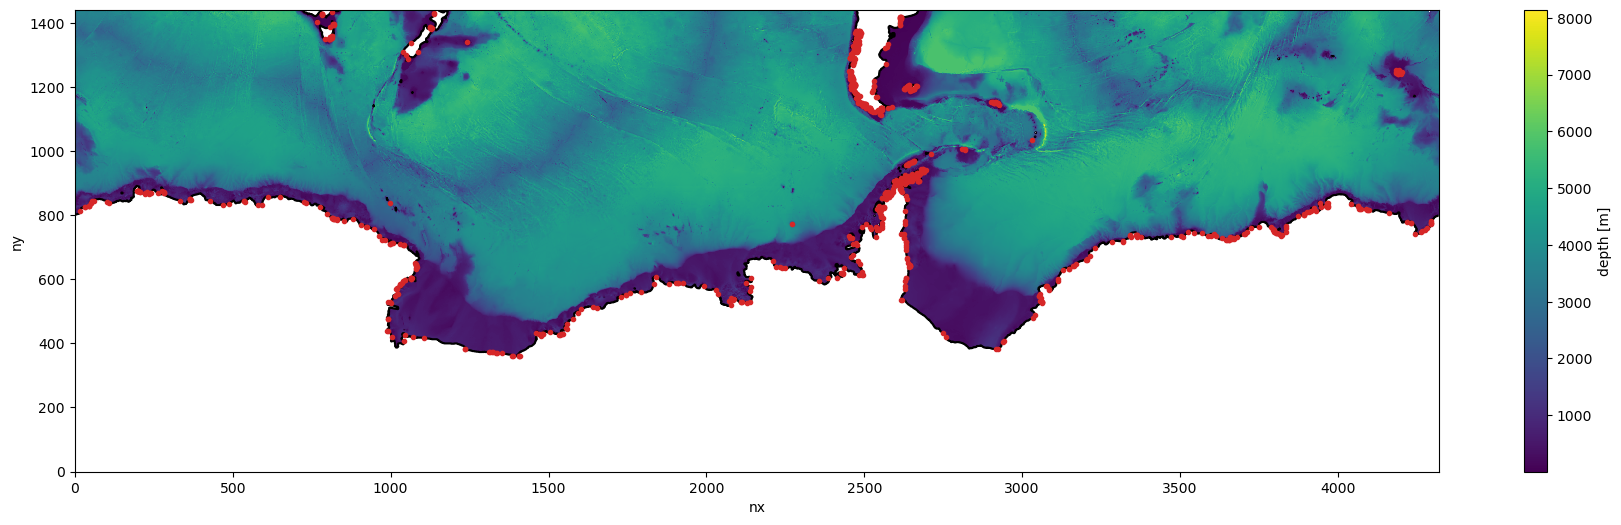

In [166]:
plt.figure(figsize=(22,6))

topog_non_advective.depth.where(topog_non_advective.depth!=0).plot()
topog_non_advective.depth.plot.contour(levels=[0,],colors='k')
plt.plot(topog_change_linearly_lined.nx,topog_change_linearly_lined.ny,linestyle='None',marker='o',markersize=3,color='tab:red')

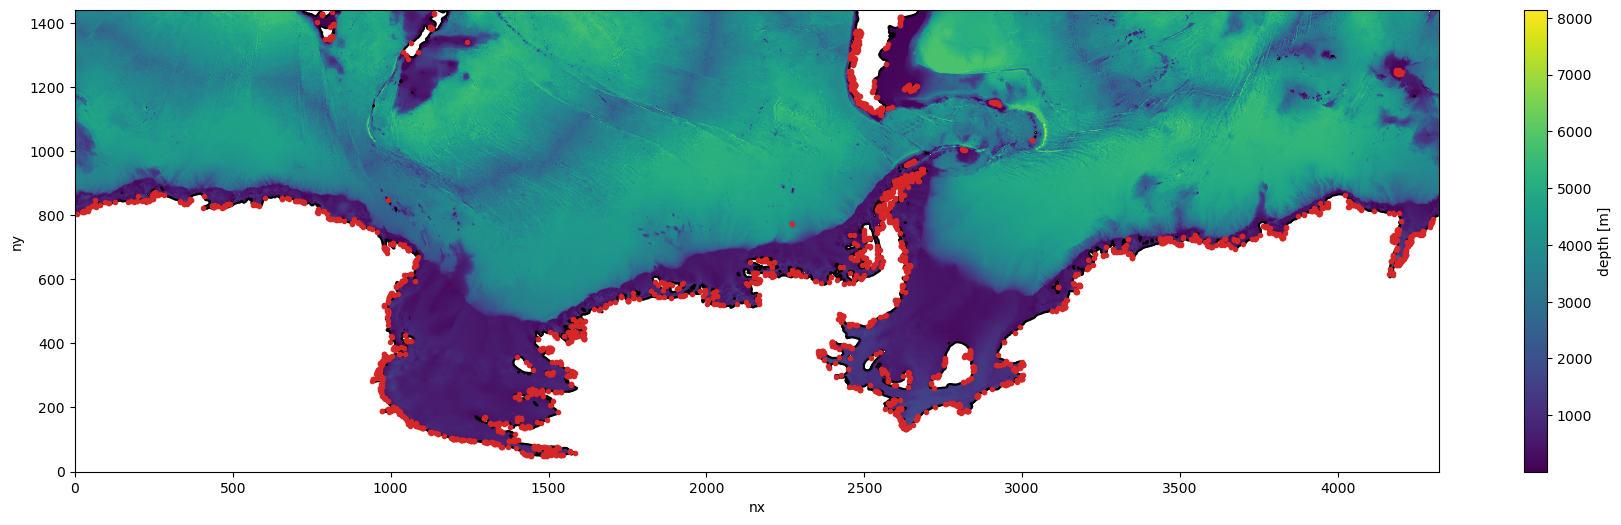

In [167]:
plt.figure(figsize=(22,6))

topog_IS_non_advective.depth.where(topog_IS_non_advective.depth!=0).plot()
topog_IS_non_advective.depth.plot.contour(levels=[0,],colors='k')
plt.plot(topog_IS_change_linearly_lined.nx,topog_IS_change_linearly_lined.ny,linestyle='None',marker='o',markersize=3,color='tab:red')

Next lets collect the points that changed in both iterations

In [74]:
pairs1 = np.array(list(zip(
    topog_IS_change_linearly_lined.nx.values,
    topog_IS_change_linearly_lined.ny.values
)))

pairs2 = np.array(list(zip(
    topog_change_linearly_lined.nx.values,
    topog_change_linearly_lined.ny.values
)))

# Convert to sets of tuples
set1 = set(map(tuple, pairs1))
set2 = set(map(tuple, pairs2))

# Find common (nx, ny) pairs
common_pairs = set1 & set2

# Create mask for dataset 1
mask = [
    (nx, ny) in common_pairs
    for nx, ny in zip(
        topog_IS_change_linearly_lined.nx.values,
        topog_IS_change_linearly_lined.ny.values
    )
]

# Select matching points
topog_change_bothfiles = topog_IS_change_linearly_lined.isel(points=mask)

Below is the the check to see which points changed when fixing non advective cells in both files. These are the points that I want to have 0 depth in `topog.nc`

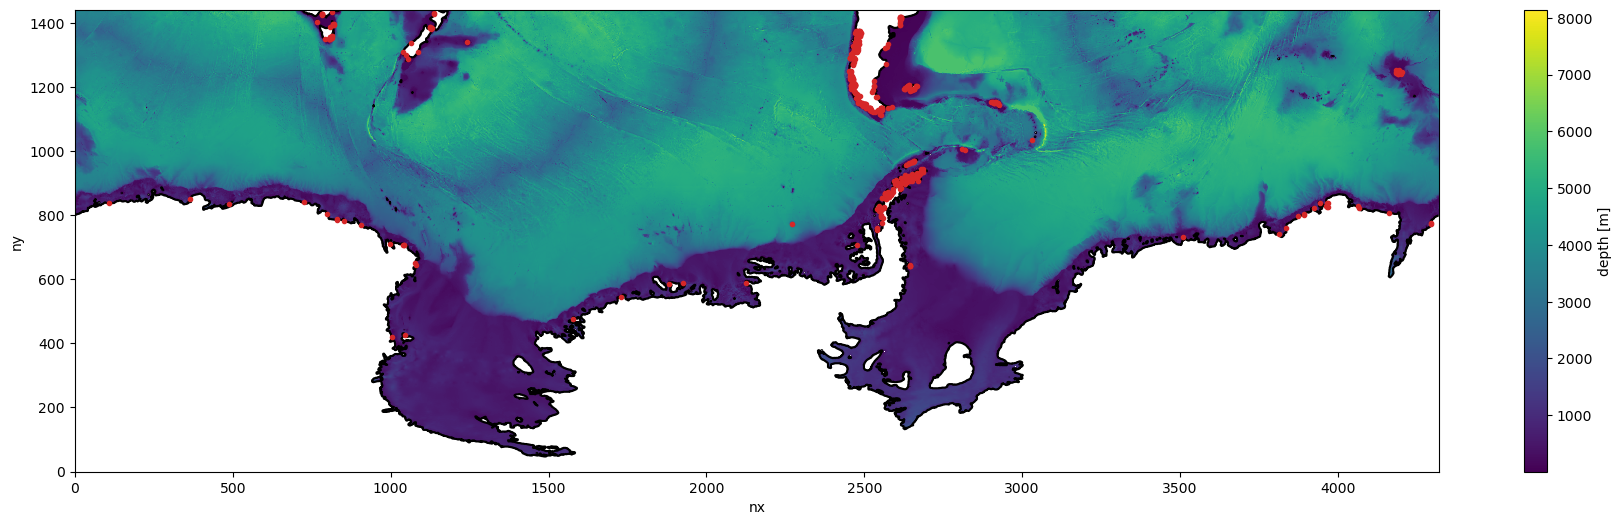

In [76]:
plt.figure(figsize=(22,6))

topog_IS_non_advective.depth.where(topog_IS_non_advective.depth!=0).plot()
topog_IS_non_advective.depth.plot.contour(levels=[0,],colors='k')
plt.plot(topog_change_bothfiles.nx,topog_change_bothfiles.ny,linestyle='None',marker='o',markersize=3,color='tab:red')

Fixing old topog files with ice shelves to have the right bathymetry now

In [90]:
from tqdm import tqdm

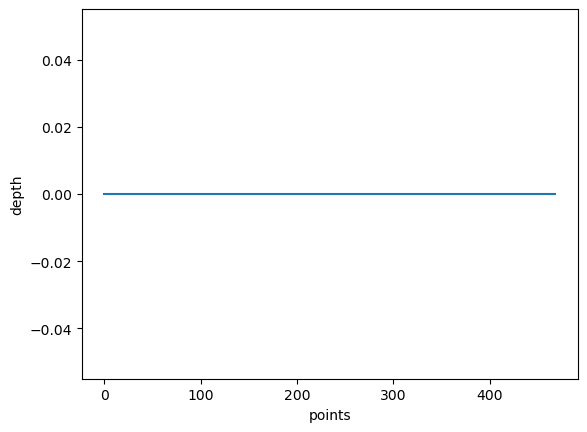

In [154]:
#let's look at the depth of these equal points in the original topog files. if they are already 0, then we dont need to changed
depth_in_orig  = topog.sel(nx = topog_change_bothfiles.nx, ny = topog_change_bothfiles.ny)
depth_in_orig.depth.plot()

In [155]:
depth_in_orig.depth.sum() # sum is 0, which means all agreeing poitns already have 0 bathymetry

<xarray.DataArray 'depth' ()> Size: 4B
array(0., dtype=float32)

It seems like all the points are 0 already in the original topog file. So we actually dont need to change topog

### Part 4 -  Fixing the ocean mask KMT

The cells removed from the bathymetry after the non-advective fix should become now land cells. For the model to understand that, we need to update the ocean mask kmt

In [160]:
#importing previous kmt
kmt_old = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/kmt.nc')

In [161]:
#replacing mask
kmt_new = kmt_old.copy()
kmt_new['kmt'].values = topog_non_advective.sea_area_fraction.values


below in blue are the cells that will be changed

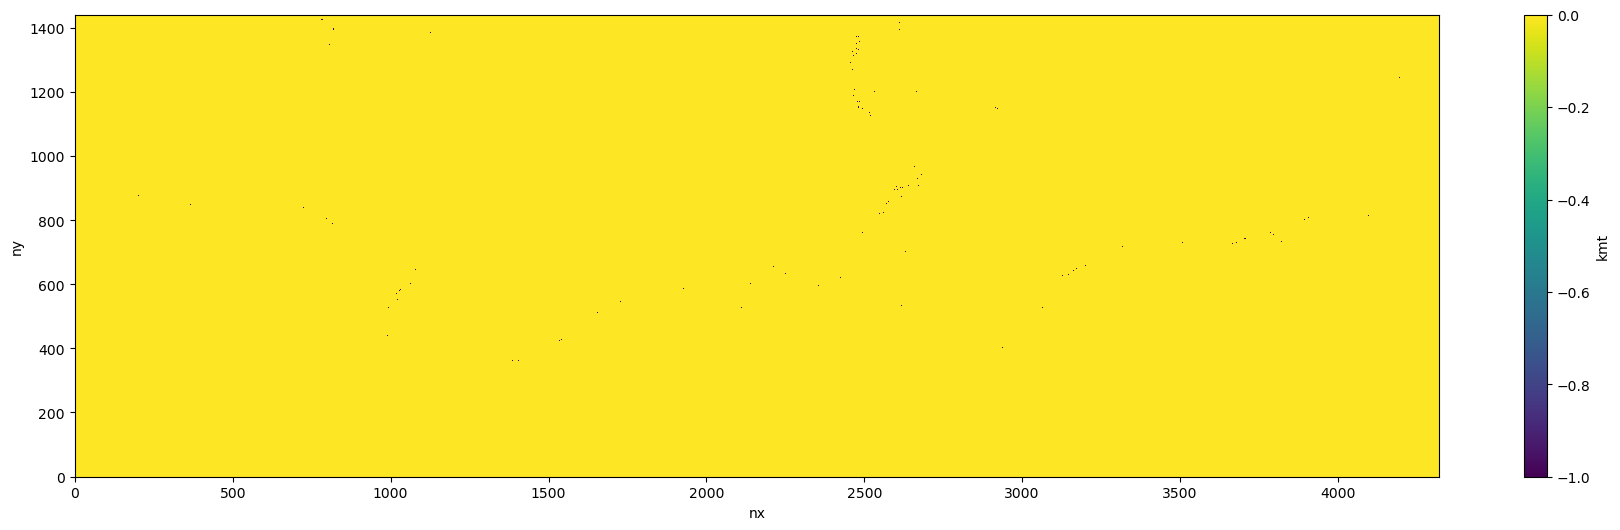

In [162]:
plt.figure(figsize=(22,6))
(kmt_new.kmt-kmt_old.kmt).plot()

In [163]:
#saving new kmt file
kmt_new.to_netcdf('/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/kmt_Bgrid.nc')

Sanity check: let's see if the kmt points are actually 0 in the new kmt file

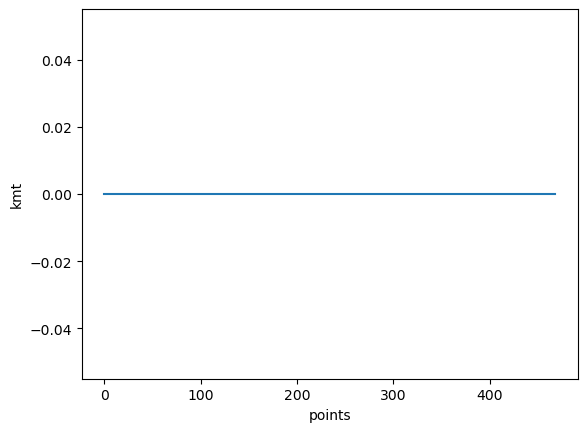

In [165]:
kmt_should_be_0 = kmt_new.kmt.sel(nx = topog_change_bothfiles.nx, ny = topog_change_bothfiles.ny)
kmt_should_be_0.plot()

all zeros, as it should be

### Part 5 -  Fixing ice shelf thickness

We dealt already with the non-advective points that should be land. Now we need to deal with the non-advective points that should be ice shelf. For that, we wll need to pick up the points present in `topog_change_linearly_lined` that arent in `topog_change_bothfiles`. This are basically points where an ice shelf should exist. We will have to change these points in the file `ice_shelf_thick.nc`. Changes to be done are:

- Change variable `thick` to be 1 cm
- Change `h_mask` to be 1
- Change `area` to be the cell area

Separating only the points that differ between `topog_change_linearly_lined` and `topog_change_bothfiles`

In [173]:
set1 = set(zip(
    topog_change_linearly_lined.nx.values,
    topog_change_linearly_lined.ny.values
))

set2 = set(zip(
    topog_change_bothfiles.nx.values,
    topog_change_bothfiles.ny.values
))


# Pairs unique to dataset 1
unique_pairs = set1 - set2

# Mask dataset 1
mask = [
    (nx, ny) in unique_pairs
    for nx, ny in zip(
        topog_change_linearly_lined.nx.values,
        topog_change_linearly_lined.ny.values
    )
]

# New dataset
topog_change_only_IS = topog_change_linearly_lined.isel(points=mask)

Below are the points that will be changed in the ice shelf thickness file

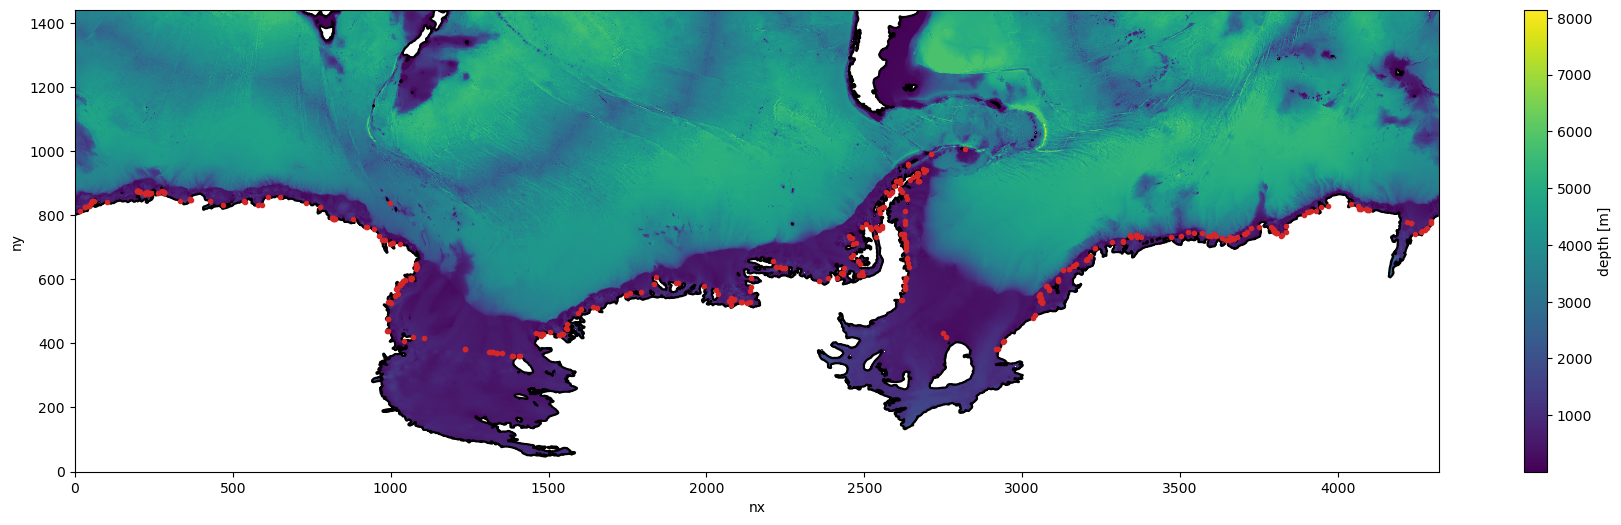

In [176]:
plt.figure(figsize=(22,6))

topog_IS_non_advective.depth.where(topog_IS_non_advective.depth!=0).plot()
topog_IS_non_advective.depth.plot.contour(levels=[0,],colors='k')
plt.plot(topog_change_only_IS.nx,topog_change_only_IS.ny,linestyle='None',marker='o',markersize=3,color='tab:red')

Those will all become ice shelves with thickness 1 cm. Let's import the required file

In [214]:
#importing original ice thickness
icethick_orig = xr.open_dataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/ice_shelf_thick.nc')
area_filled = (icethick_orig.area.where(icethick_orig.area!=0)).bfill('nx').ffill('nx') # will be used to collect the area that needs to be addded in the new ice shelf points
# the value that will be added to the ice shelf thickess will be 1 cm
new_ICT = 1/100

In [215]:
icethick_edit = icethick_orig.copy(deep=True)

for k in range(topog_change_only_IS.sizes["points"]):
    i = int(topog_change_only_IS.nx.values[k])
    j = int(topog_change_only_IS.ny.values[k])
    # first changing ice thickness to 1 cm
    icethick_edit["thick"].values[j, i] = new_ICT
    # Second changing mask to 1
    icethick_edit["h_mask"].values[j, i] = 1
    # finally assiging area to the ice shelf
    icethick_edit["area"].values[j, i] = area_filled.values[j, i]

lets check the differences between the old icethick and the new one, as a sanity check

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0., 369.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-0.49000001, -0.45666668, -0.42333335, -0.38999999, -0.35666665,
        -0.32333332, -0.28999999, -0.25666666, -0.22333333, -0.19      ,
        -0.15666667, -0.12333333, -0.09      , -0.05666667, -0.02333333,
         0.01      ,  0.04333333,  0.07666667,  0.11      ,  0.14333333,
         0.17666666,  0.20999999,  0.24333334,  0.27666667,  0.31      ,
         0.34333333,  0.37666667,  0.41      ,  0.44333333,  0.47666666,
         0.50999999]),
 <BarContainer object of 30 artists>)

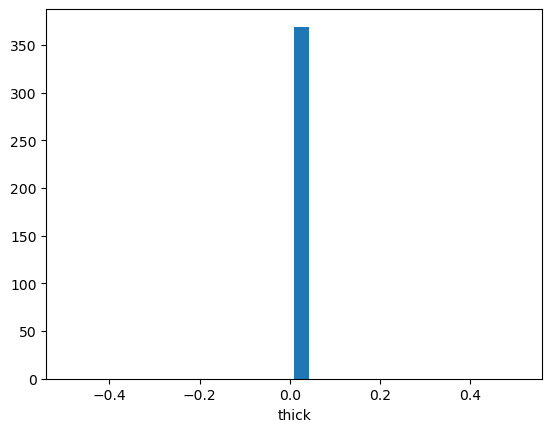

In [217]:
#sanity check of thicknessess
thickdiff = (icethick_edit.thick - icethick_orig.thick)
thickdiff = thickdiff.where(thickdiff!=0)
thickdiff.plot.hist(bins=30) # it should all be equal to 0.01

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0., 369.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        , 1.03333333, 1.06666667, 1.1       , 1.13333333,
        1.16666667, 1.2       , 1.23333333, 1.26666667, 1.3       ,
        1.33333333, 1.36666667, 1.4       , 1.43333333, 1.46666667,
        1.5       ]),
 <BarContainer object of 30 artists>)

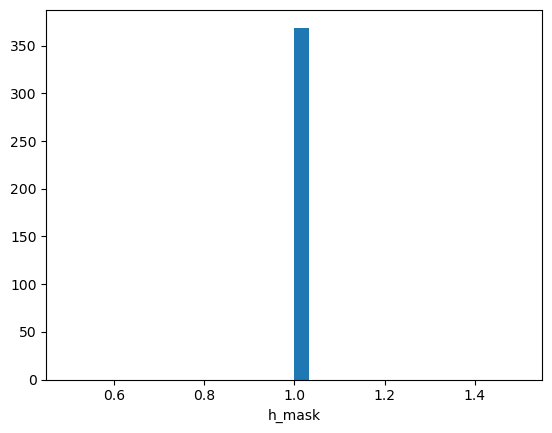

In [218]:
#sanity check of hmask
thickdiff = (icethick_edit.h_mask - icethick_orig.h_mask)
thickdiff = thickdiff.where(thickdiff!=0)
thickdiff.plot.hist(bins=30) # it should all be equal to 1

(array([25., 20., 25., 20., 31., 13., 18.,  9.,  3., 18., 37., 25., 12.,
        10.,  8., 19., 16.,  8., 17., 10.,  3.,  8.,  1.,  4.,  1.,  1.,
         0.,  0.,  1.,  1.]),
 array([ 4350042.17205223,  4893034.98647091,  5436027.8008896 ,
         5979020.61530829,  6522013.42972697,  7065006.24414566,
         7607999.05856435,  8150991.87298303,  8693984.68740172,
         9236977.50182041,  9779970.3162391 , 10322963.13065778,
        10865955.94507647, 11408948.75949516, 11951941.57391385,
        12494934.38833253, 13037927.20275122, 13580920.01716991,
        14123912.83158859, 14666905.64600728, 15209898.46042597,
        15752891.27484466, 16295884.08926334, 16838876.90368203,
        17381869.71810072, 17924862.5325194 , 18467855.34693809,
        19010848.16135678, 19553840.97577547, 20096833.79019415,
        20639826.60461284]),
 <BarContainer object of 30 artists>)

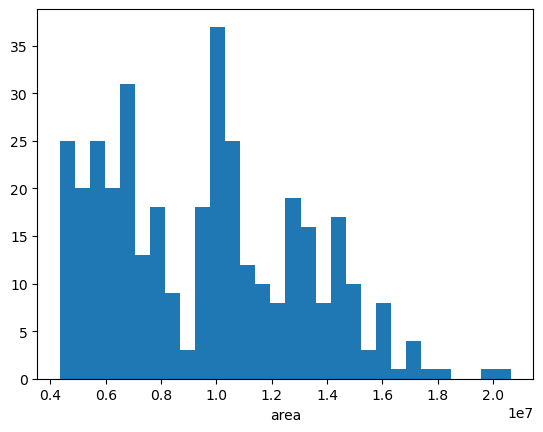

In [219]:
#sanity check of area
thickdiff = (icethick_edit.area - icethick_orig.area)
thickdiff = thickdiff.where(thickdiff!=0)
thickdiff.plot.hist(bins=30) # it should have various values, but no zeros

It looks like the data was correctly fixed. let's save the netcdf 

In [221]:
icethick_edit.to_netcdf('/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/ice_shelf_thick_Bgrid.nc')

Legend for new files:

- `kmt.nc` = `kmt_Bgrid.nc`
- `topog.nc`  = `topog_IS_with_sea_fraction_Bgrid_non_advective.nc`
- `topog_seaice.nc` = `topog_with_sea_fraction_Bgrid_non_advective.nc`
- `ice_shelf_thick.nc` = `ice_shelf_thick_Bgrid.nc`


all files are in `/g/data/ik11/users/wf4500/panan_ice_modelling_position/GH/Bathymetry_tools_OM3/make_om3_topo/claires_input/`

Check masks to see if they add up